In [1]:
# ─────────────────────────────────────────────
# [C1] Part 0 · ⚙️ 환경 설정과 실습 데이터 환경 준비 — 모든 import를 여기 모읍니다 (순서 실행 안전)
# ─────────────────────────────────────────────
import platform, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import silhouette_score, silhouette_samples

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
import matplotlib.font_manager as fm

# 한글 폰트 설정 — 그래프의 한글이 □□□로 깨지지 않게 합니다
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:                                        # 코랩 등 리눅스 — 나눔고딕을 설치해야 합니다
    if not any("Nanum" in f.name for f in fm.fontManager.ttflist):
        print("나눔고딕을 설치합니다 (10~20초 걸립니다)...")
        import subprocess
        subprocess.run("apt-get install -y -qq fonts-nanum", shell=True, capture_output=True)
        for path in fm.findSystemFonts(fontpaths=["/usr/share/fonts/truetype/nanum"]):
            fm.fontManager.addfont(path)
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", font=plt.rcParams["font.family"])
print("준비 완료 ✓")

준비 완료 ✓


In [2]:
import urllib.request

# 펭귄 데이터 자동 다운로드
penguin_url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
save_path = Path("assets/datasets/penguins.csv")
save_path.parent.mkdir(parents=True, exist_ok=True)

if not save_path.exists():
    urllib.request.urlretrieve(penguin_url, save_path)
    print(f"✅ penguins.csv 다운로드 완료: {save_path}")

In [3]:
# ─────────────────────────────────────────────
# [C2] Part 0 · ⚙️ 환경 설정과 실습 데이터 실습 데이터 준비 — 합성 3종 + 실데이터 1종
# (실행하면 네 데이터의 크기와 고객 데이터 요약이 출력됩니다)
# ─────────────────────────────────────────────
# 실행 위치가 저장소 루트·notebooks·v2.1_ing 중 어디인지에 따라 동봉 파일을 찾습니다.
PENGUIN_CANDIDATES = [
    Path("output/notebooks/assets/datasets/penguins.csv"),
    Path("assets/datasets/penguins.csv"),
    Path("../assets/datasets/penguins.csv"),
]
penguin_path = next((p for p in PENGUIN_CANDIDATES if p.exists()), None)
if penguin_path is None:
    raise FileNotFoundError("동봉된 penguins.csv를 찾을 수 없습니다. assets/datasets 배치를 확인합니다.")

# (A) 깔끔한 군집 4개 — K-Means·실루엣 연습용
X_blob, y_blob = make_blobs(n_samples=500, centers=4, cluster_std=1.0,
                            random_state=RANDOM_STATE)
# (B) 초승달 2개 — DBSCAN이 빛나는 비구형
X_moon, _ = make_moons(n_samples=400, noise=0.06, random_state=RANDOM_STATE)

# (C) 펭귄 실데이터 — 실루엣을 실데이터에서 확인할 때
peng = pd.read_csv(penguin_path)
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
peng = peng.dropna(subset=num_cols).reset_index(drop=True)


# (D) 모두플레이 구독자 데이터 — 오늘의 메인. 세그먼트 해석과 피처화에 씁니다
def make_moduplay_customers(n=1200, seed=RANDOM_STATE):
    """모두플레이 구독자 데이터를 만듭니다. 3개 세그먼트 구조를 심어 둡니다.

    열 이름은 지난 시간들과 같습니다 — 실무에서는 pd.read_csv 자리입니다.
    시드를 고정했으니 결과가 항상 같습니다.
    """
    rng = np.random.default_rng(seed)
    seg = rng.choice([0, 1, 2], n, p=[0.45, 0.30, 0.25])
    #        (지난달 시청 시간, 월 세션 수, 마지막 시청 후 경과일)
    center = {0: (9, 2.2, 20), 1: (44, 9.5, 2), 2: (25, 5.5, 48)}
    # 음수가 나오지 않게 최솟값을 눌러 둡니다 (시청 시간·세션 수·경과일은 음수가 될 수 없습니다)
    watch = np.clip(np.array([center[s][0] for s in seg]) + rng.normal(0, 4.0, n), 0.2, None)
    sess = np.clip(np.array([center[s][1] for s in seg]) + rng.normal(0, 1.0, n), 0, None)
    recency = np.clip(np.array([center[s][2] for s in seg]) + rng.normal(0, 6.0, n), 0, None)
    # 이탈은 '세그먼트 정체성'이 좌우합니다 (선형으로 잡기 어려운 구조)
    churn_rate = {0: 0.18, 1: 0.06, 2: 0.55}
    churn = rng.binomial(1, [churn_rate[s] for s in seg])
    return pd.DataFrame({
        "watch_hours_last_month": watch.round(1),   # 지난달 시청 시간
        "sessions_per_month": sess.round(2),        # 월 시청 세션 수
        "days_since_last_watch": recency.round(0),  # 마지막 시청 후 경과일
        "churn": churn,                             # 이탈 여부 (Part 7에서만 씁니다)
    })


cust = make_moduplay_customers()
CUST_FEAT = ["watch_hours_last_month", "sessions_per_month", "days_since_last_watch"]

print(f"(A) make_blobs {X_blob.shape}  (B) make_moons {X_moon.shape}  (C) penguins {peng.shape}")
print(f"(D) 모두플레이 구독자 {cust.shape}  이탈률 {cust['churn'].mean():.3f}")
print()
print(cust[CUST_FEAT].describe().round(1).to_string())
print()
print("→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.")
print("  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는 셈입니다.")

(A) make_blobs (500, 2)  (B) make_moons (400, 2)  (C) penguins (342, 7)
(D) 모두플레이 구독자 (1200, 4)  이탈률 0.241

       watch_hours_last_month  sessions_per_month  days_since_last_watch
count                  1200.0              1200.0                 1200.0
mean                     23.1                 5.2                   22.4
std                      15.3                 3.2                   17.5
min                       0.2                 0.0                    0.0
25%                       9.5                 2.4                    7.8
50%                      21.4                 4.6                   19.0
75%                      39.1                 8.5                   38.0
max                      55.7                12.6                   65.0

→ 합성 데이터는 '정답 구조'를 알고 만들지만, 군집 알고리즘에는 정답 없이 X만 줍니다.
  고객 데이터의 churn은 Part 7까지 쓰지 않습니다 — 지금은 정답이 없는 셈입니다.


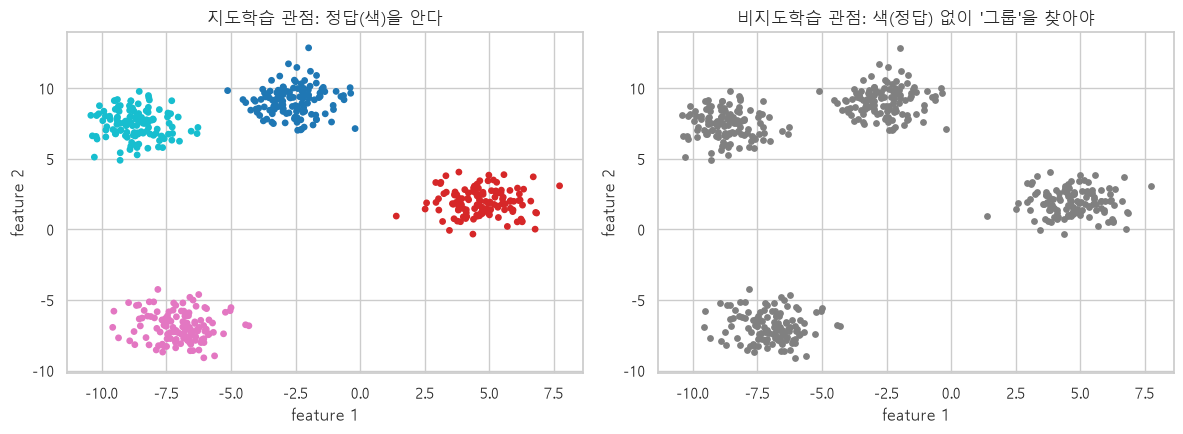

→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.


In [4]:
# ─────────────────────────────────────────────
# [C3] Part 1 · 📊 데이터로 확인해 봅시다 — 같은 데이터, 다른 시작점 [도식] 지도(정답 색칠) vs 비지도(색 없음) — 같은 데이터, 다른 시작점
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap="tab10", s=15)
axes[0].set_title("지도학습 관점: 정답(색)을 안다")
axes[1].scatter(X_blob[:, 0], X_blob[:, 1], c="gray", s=15)
axes[1].set_title("비지도학습 관점: 색(정답) 없이 '그룹'을 찾아야")
for ax in axes: ax.set_xlabel("feature 1"); ax.set_ylabel("feature 2")
plt.tight_layout(); plt.show()
print("→ 오른쪽처럼 '정답 색이 없는' 회색 점들에서, 알고리즘이 스스로 그룹을 찾는 게 군집화입니다.")

Exception in thread Thread-5 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "c:\Users\spide\anaconda3\envs\myenv\Lib\codecs.py", line 322, in decode
    (result, consumed) = self._buffer_decode(data, self.errors, final)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


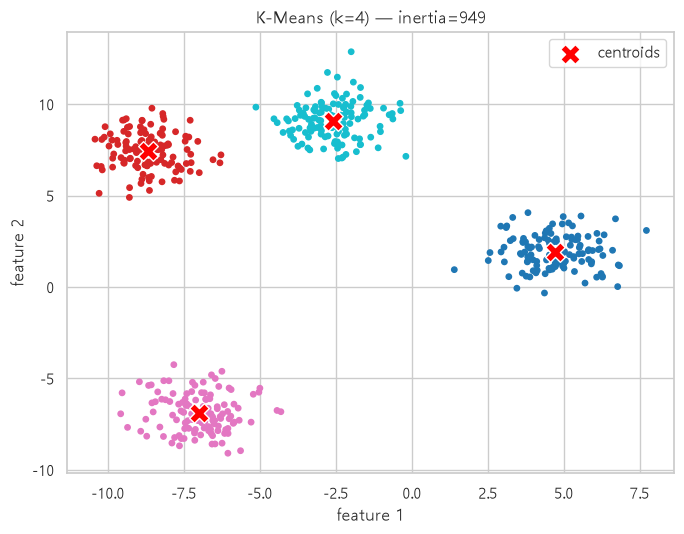

→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.


In [5]:
# ─────────────────────────────────────────────
# [C4] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means로 make_blobs를 군집화 (정답 없이 X만 준다)
# ─────────────────────────────────────────────
km = KMeans(n_clusters=4, n_init=10, random_state=RANDOM_STATE)
labels = km.fit_predict(X_blob)        # 각 점의 군집 번호(0~3)

plt.figure(figsize=(7, 5.5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, cmap="tab10", s=15)
plt.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
            c="red", marker="X", s=200, edgecolor="white", label="centroids")
plt.title(f"K-Means (k=4) — inertia={km.inertia_:.0f}")
plt.xlabel("feature 1"); plt.ylabel("feature 2"); plt.legend()
plt.tight_layout(); plt.show()
print("→ 빨간 X가 각 군집의 '중심'입니다. 정답 색 없이도 네 덩어리를 잘 찾아냈습니다.")

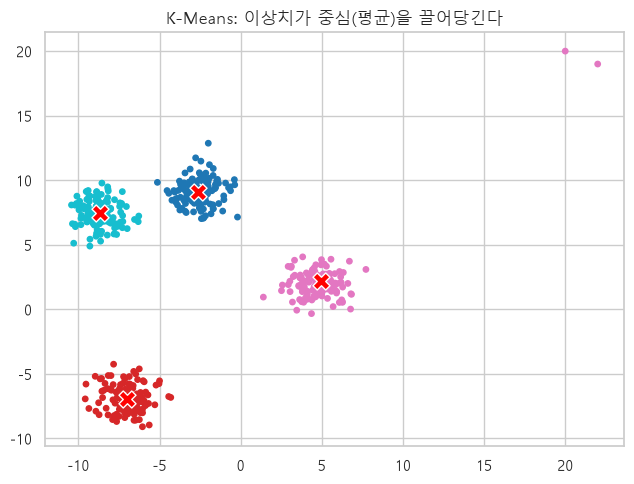

→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.


In [6]:
# [C5] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means의 약점 — 이상치에 끌려가는 중심
import numpy as np
X_out = np.vstack([X_blob, [[20, 20], [22, 19]]])    # 멀리 떨어진 이상치 2개 추가
lb_out = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X_out)
plt.figure(figsize=(6.5, 5))
plt.scatter(X_out[:, 0], X_out[:, 1], c=lb_out.labels_, cmap="tab10", s=15)
plt.scatter(lb_out.cluster_centers_[:, 0], lb_out.cluster_centers_[:, 1], c="red", marker="X", s=150, edgecolor="white")
plt.title("K-Means: 이상치가 중심(평균)을 끌어당긴다")
plt.tight_layout(); plt.show()
print("→ K-Means는 '평균'으로 중심을 잡아 이상치에 민감합니다. DBSCAN은 설정한 밀도 기준에 따라 이런 점을 잡음 후보로 분리할 수 있습니다.")

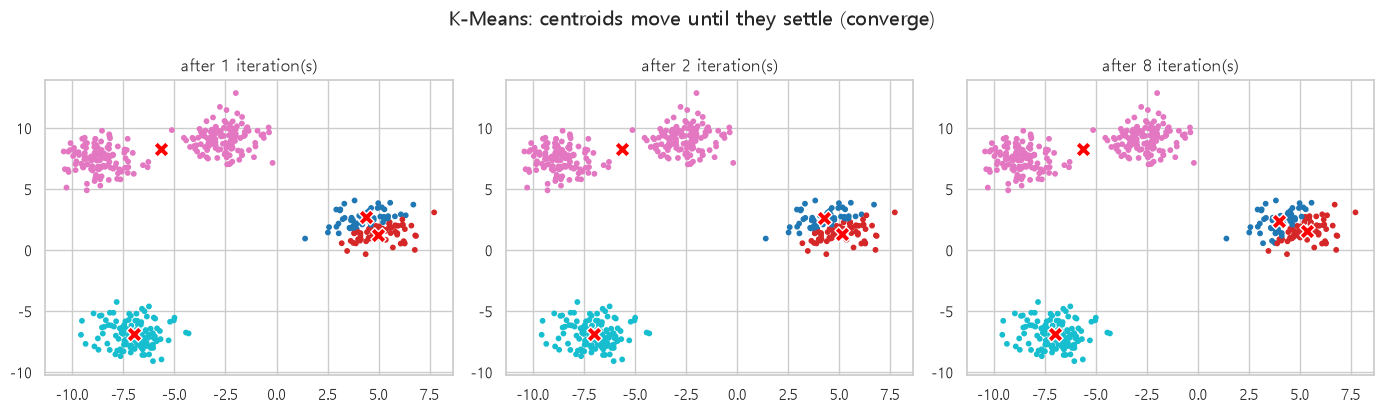

→ 반복할수록 중심이 자리를 잡습니다. 어느 순간부터 거의 안 움직이면 '수렴'한 것.


In [7]:
# [C6] Part 2 · 📊 데이터로 확인해 봅시다 — K-Means를 돌려 보기 K-Means 중심이 반복마다 이동하는 과정 (max_iter를 1,2,5로)
import numpy as np
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, it in zip(axes, [1, 2, 8]):
    m = KMeans(n_clusters=4, init="random", n_init=1, max_iter=it, random_state=1).fit(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=m.labels_, cmap="tab10", s=10)
    ax.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1], c="red", marker="X", s=120, edgecolor="white")
    ax.set_title(f"after {it} iteration(s)")
plt.suptitle("K-Means: centroids move until they settle (converge)")
plt.tight_layout(); plt.show()
print("→ 반복할수록 중심이 자리를 잡습니다. 어느 순간부터 거의 안 움직이면 '수렴'한 것.")

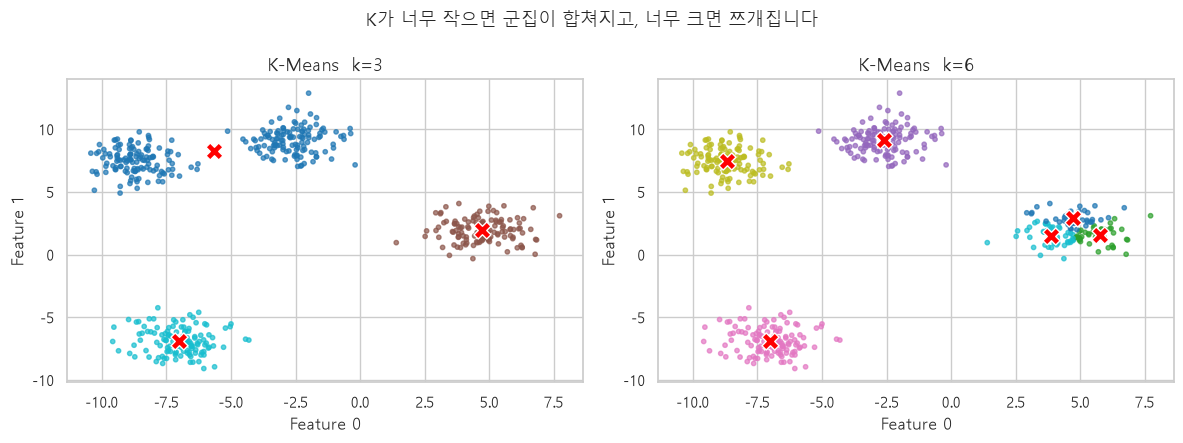

→ k=3: 실제 4개 군집 중 둘이 하나로 합쳐져 경계가 어색합니다.
→ k=6: 하나의 자연 군집이 2~3개로 쪼개져 과분할 됩니다.
   정답(k=4)과 비교하면 K 선택이 얼마나 중요한지 체감됩니다.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, k in zip(axes, [3, 6]):
    m = KMeans(n_clusters=k, init="random", n_init=1, max_iter=8, random_state=1).fit(X_blob)
    ax.scatter(X_blob[:, 0], X_blob[:, 1], c=m.labels_, cmap="tab10", s=10, alpha=0.7)
    ax.scatter(m.cluster_centers_[:, 0], m.cluster_centers_[:, 1],
               c="red", marker="X", s=150, edgecolor="white", zorder=5)
    ax.set_title(f"K-Means  k={k}", fontsize=13)
    ax.set_xlabel("Feature 0")
    ax.set_ylabel("Feature 1")

plt.suptitle("K가 너무 작으면 군집이 합쳐지고, 너무 크면 쪼개집니다", fontsize=13)
plt.tight_layout()
plt.show()

print("→ k=3: 실제 4개 군집 중 둘이 하나로 합쳐져 경계가 어색합니다.")
print("→ k=6: 하나의 자연 군집이 2~3개로 쪼개져 과분할 됩니다.")
print("   정답(k=4)과 비교하면 K 선택이 얼마나 중요한지 체감됩니다.")

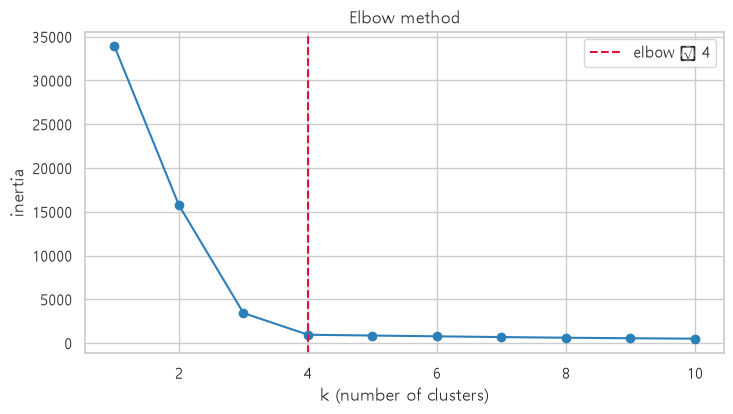

→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.


In [9]:
# ─────────────────────────────────────────────
# [C8] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Elbow — k에 따른 inertia
# ─────────────────────────────────────────────
ks = range(1, 11)
inertias = [KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blob).inertia_ for k in ks]
plt.figure(figsize=(7.5, 4.3))
plt.plot(list(ks), inertias, "o-", color="#2c7fb8")
plt.axvline(4, ls="--", color="crimson", label="elbow ≈ 4")
plt.xlabel("k (number of clusters)"); plt.ylabel("inertia")
plt.title("Elbow method"); plt.legend(); plt.tight_layout(); plt.show()
print("→ k=4 부근에서 '꺾임'이 보입니다. 그 뒤로는 k를 늘려도 inertia가 완만히 줄 뿐입니다.")

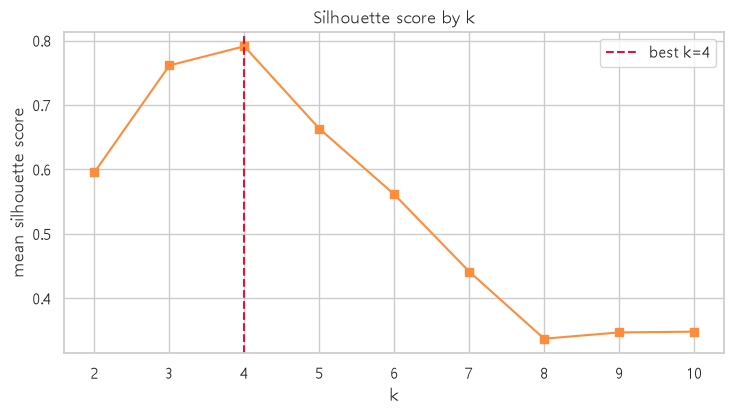

→ 실루엣 점수가 가장 높은 k=4. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.


In [10]:
# ─────────────────────────────────────────────
# [C9] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 Silhouette — k에 따른 평균 실루엣 점수
# ─────────────────────────────────────────────
sil = []
for k in range(2, 11):     # 실루엣은 k>=2
    lb = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit_predict(X_blob)
    sil.append(silhouette_score(X_blob, lb))
plt.figure(figsize=(7.5, 4.3))
plt.plot(range(2, 11), sil, "s-", color="#fd8d3c")
best_k = list(range(2, 11))[int(np.argmax(sil))]
plt.axvline(best_k, ls="--", color="crimson", label=f"best k={best_k}")
plt.xlabel("k"); plt.ylabel("mean silhouette score")
plt.title("Silhouette score by k"); plt.legend(); plt.tight_layout(); plt.show()
print(f"→ 실루엣 점수가 가장 높은 k={best_k}. Elbow와 같은 k를 지지하지만 정답이 확정되는 것은 아닙니다.")

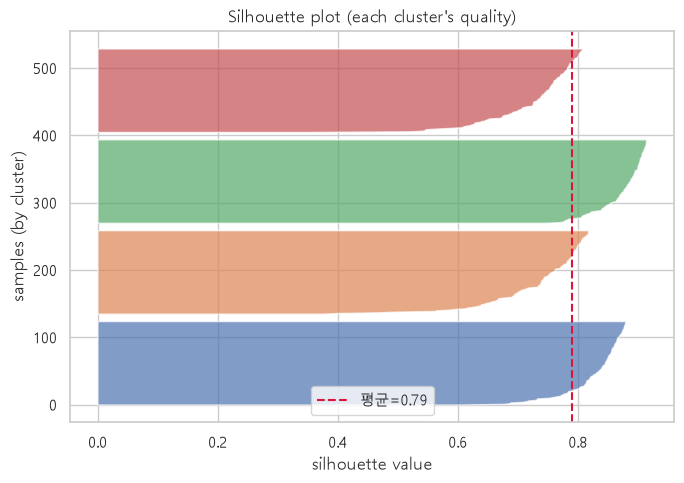

→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.


In [11]:
# [C10] Part 3 · 📊 데이터로 확인해 봅시다 — Elbow와 실루엣을 직접 그려 보기 실루엣 플롯 — 군집별 품질 분포
labels4 = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(X_blob)
sv = silhouette_samples(X_blob, labels4)
fig, ax = plt.subplots(figsize=(7, 5)); y_low = 0
for i in range(4):
    vals = np.sort(sv[labels4 == i])
    ax.fill_betweenx(np.arange(y_low, y_low + len(vals)), 0, vals, alpha=0.7)
    y_low += len(vals) + 10
ax.axvline(sv.mean(), color="crimson", ls="--", label=f"평균={sv.mean():.2f}")
ax.set_xlabel("silhouette value"); ax.set_ylabel("samples (by cluster)")
ax.set_title("Silhouette plot (each cluster's quality)"); ax.legend()
plt.tight_layout(); plt.show()
print("→ 각 군집의 실루엣 분포. 세로 길이는 군집 크기, 가로 길이는 점별 Silhouette입니다. 음수 값은 경계가 모호한 점을 뜻합니다.")

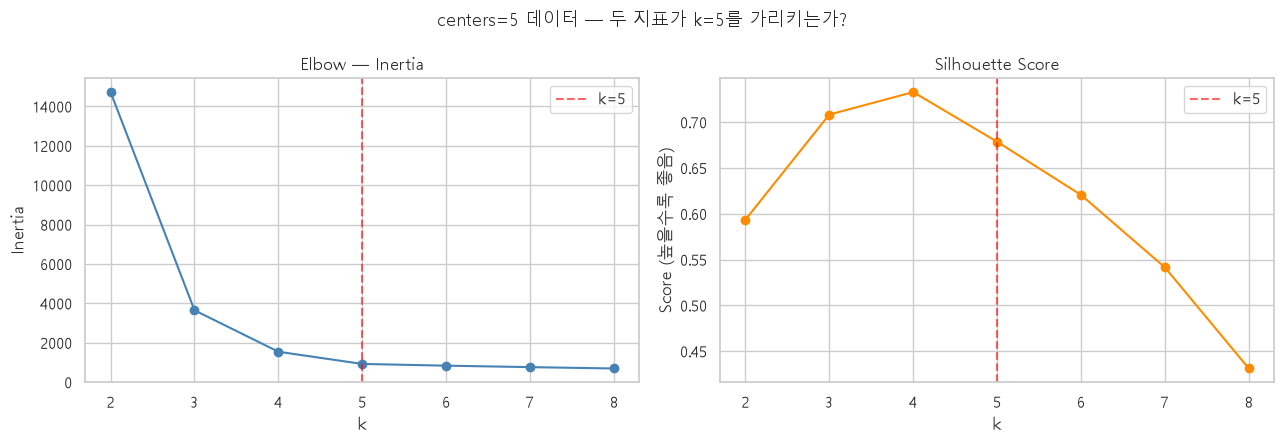

  k     Inertia  Silhouette
----------------------------
  2     14726.1      0.5936
  3      3648.8      0.7084
  4      1543.4      0.7328
  5       924.0      0.6786 ◀ best
  6       836.1      0.6206
  7       762.0      0.5415
  8       693.1      0.4312


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 1) centers=5로 새 데이터 생성 ──────────────────────────────
X_blob5, y_blob5 = make_blobs(n_samples=500, centers=5, cluster_std=1.0,
                               random_state=RANDOM_STATE)

# ── 2) k=2~8 구간에서 Inertia · Silhouette 계산 ────────────────
k_range = range(2, 9)
inertias, sil_scores = [], []

for k in k_range:
    m = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_blob5)
    inertias.append(m.inertia_)
    sil_scores.append(silhouette_score(X_blob5, m.labels_))

# ── 시각화 ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Elbow
axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].axvline(5, color="red", linestyle="--", alpha=0.6, label="k=5")
axes[0].set_title("Elbow — Inertia")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].legend()

# Silhouette
axes[1].plot(k_range, sil_scores, marker="o", color="darkorange")
axes[1].axvline(5, color="red", linestyle="--", alpha=0.6, label="k=5")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score (높을수록 좋음)")
axes[1].legend()

plt.suptitle("centers=5 데이터 — 두 지표가 k=5를 가리키는가?", fontsize=13)
plt.tight_layout()
plt.show()

# ── 수치 출력 ───────────────────────────────────────────────────
print(f"{'k':>3}  {'Inertia':>10}  {'Silhouette':>10}")
print("-" * 28)
for k, ine, sil in zip(k_range, inertias, sil_scores):
    marker = " ◀ best" if k == 5 else ""
    print(f"{k:>3}  {ine:>10.1f}  {sil:>10.4f}{marker}")

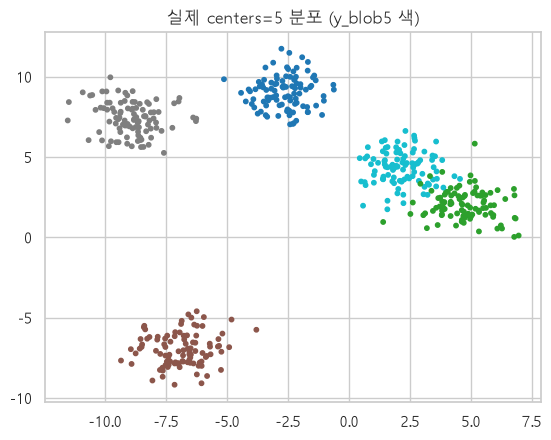

In [13]:
# 실제 군집이 얼마나 분리되어 있는지 눈으로 확인
plt.scatter(X_blob5[:, 0], X_blob5[:, 1], c=y_blob5, cmap="tab10", s=10)
plt.title("실제 centers=5 분포 (y_blob5 색)")
plt.show()

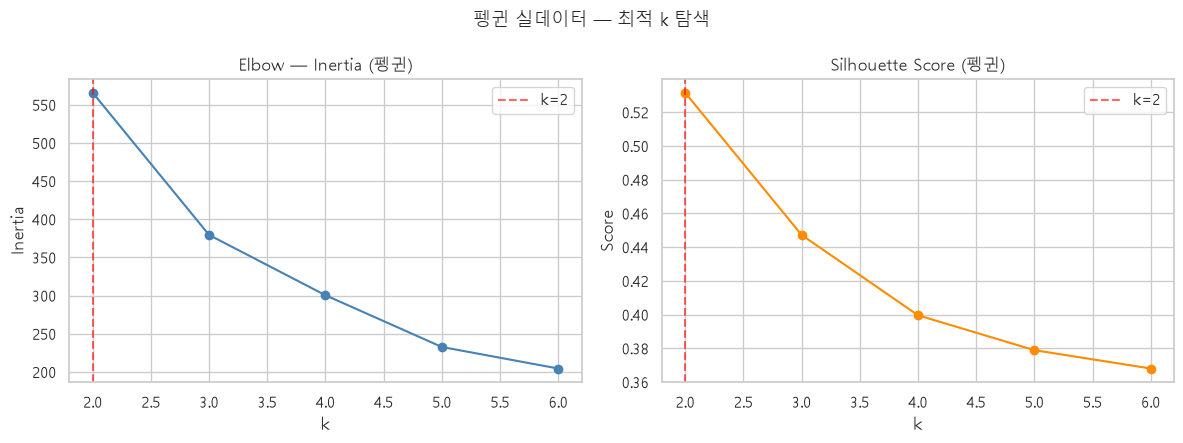

  k     Inertia  Silhouette
----------------------------
  2       565.7      0.5315 ◀ best
  3       379.4      0.4472
  4       300.4      0.3996
  5       232.6      0.3789
  6       204.4      0.3680

→ Silhouette 기준 최적 k = 2
  (펭귄은 종(species)이 3종이라 도메인 지식상 k=3도 유력한 후보)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 1) 수치 컬럼 표준화 ────────────────────────────────────────
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X_peng = StandardScaler().fit_transform(peng[num_cols])

# ── 2) k=2~6 Silhouette 계산 ──────────────────────────────────
k_range = range(2, 7)
inertias, sil_scores = [], []

for k in k_range:
    m = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_peng)
    inertias.append(m.inertia_)
    sil_scores.append(silhouette_score(X_peng, m.labels_))

# ── 시각화 ────────────────────────────────────────────────────
best_k = k_range.start + sil_scores.index(max(sil_scores))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(k_range, inertias, marker="o", color="steelblue")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k={best_k}")
axes[0].set_title("Elbow — Inertia (펭귄)")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].legend()

axes[1].plot(k_range, sil_scores, marker="o", color="darkorange")
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"k={best_k}")
axes[1].set_title("Silhouette Score (펭귄)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Score")
axes[1].legend()

plt.suptitle("펭귄 실데이터 — 최적 k 탐색", fontsize=13)
plt.tight_layout()
plt.show()

# ── 수치 출력 ─────────────────────────────────────────────────
print(f"{'k':>3}  {'Inertia':>10}  {'Silhouette':>10}")
print("-" * 28)
for k, ine, sil in zip(k_range, inertias, sil_scores):
    marker = " ◀ best" if k == best_k else ""
    print(f"{k:>3}  {ine:>10.1f}  {sil:>10.4f}{marker}")

print(f"\n→ Silhouette 기준 최적 k = {best_k}")
print(f"  (펭귄은 종(species)이 3종이라 도메인 지식상 k=3도 유력한 후보)")

실무 판단 순서

1순위 — 도메인 지식 활용
펭귄은 종이 3종(Adelie·Chinstrap·Gentoo)이라는 걸 알고 있으니 → k=3 채택

2순위 — 군집이 해석 가능한가
k=2면 "큰 펭귄 vs 작은 펭귄"처럼 너무 뭉뚱그려짐. k=3이면 종별 특징을 설명할 수 있음

3순위 — 비용/활용 목적
마케팅 세그먼트라면 "담당자가 실제로 다르게 대응할 수 있는 수"가 적정 k

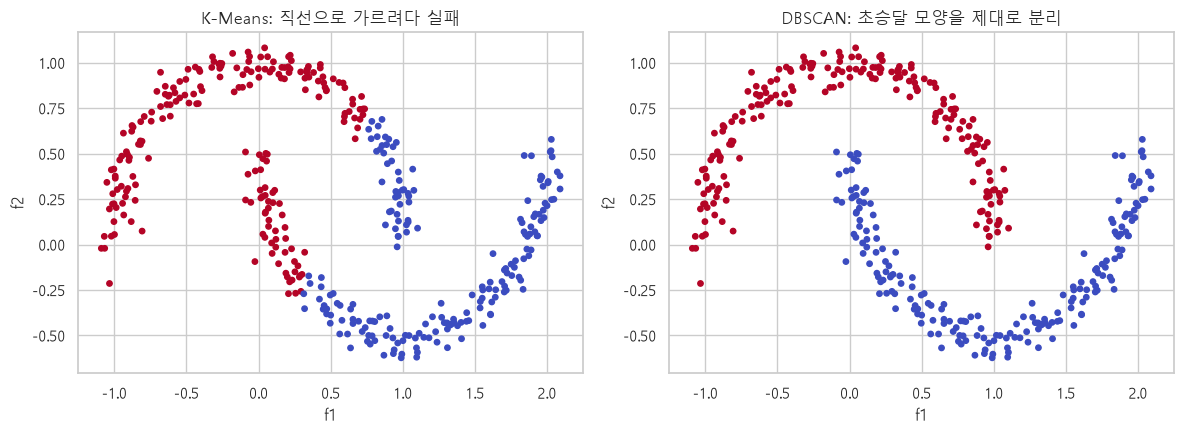

→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.


In [15]:
# ─────────────────────────────────────────────
# [C13] Part 4 · 📊 데이터로 확인해 봅시다 — 초승달 데이터에서 두 알고리즘을 비교 K-Means vs DBSCAN — 초승달(make_moons)에서 누가 옳은가
# ─────────────────────────────────────────────
km_moon = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(X_moon)
db_moon = DBSCAN(eps=0.2, min_samples=5).fit_predict(X_moon)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c=km_moon, cmap="coolwarm", s=15)
axes[0].set_title("K-Means: 직선으로 가르려다 실패")
axes[1].scatter(X_moon[:, 0], X_moon[:, 1], c=db_moon, cmap="coolwarm", s=15)
axes[1].set_title("DBSCAN: 초승달 모양을 제대로 분리")
for ax in axes: ax.set_xlabel("f1"); ax.set_ylabel("f2")
plt.tight_layout(); plt.show()
print("→ K-Means는 '둥근 군집' 가정 때문에 초승달을 가로질러 자릅니다. DBSCAN은 밀도로 따라가 성공.")

In [16]:
# ─────────────────────────────────────────────
# [C14] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 와인 13피처 → PCA — 실행하면 주성분별·누적 설명 분산비가 출력됩니다
# ─────────────────────────────────────────────
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target      # y는 채점용으로만 보관합니다

print(f"와인 데이터: {X_wine.shape[0]}병 × {X_wine.shape[1]}개 성분")
print(f"품종 분포: {y_wine.value_counts().sort_index().to_dict()}")

# ① 표준화 — PCA 앞에서는 거의 필수입니다
Xw = StandardScaler().fit_transform(X_wine)

# ② 주성분을 전부 뽑아 설명 분산비를 봅니다
pca_all = PCA(random_state=RANDOM_STATE).fit(Xw)
ratio = pca_all.explained_variance_ratio_
cum = np.cumsum(ratio)

print("\n주성분별 설명 분산비 (상위 5개)")
for i in range(5):
    print(f"  PC{i+1}: {ratio[i]:.3f}   누적 {cum[i]:.3f}")

n90 = int(np.argmax(cum >= 0.90)) + 1
print(f"\nPC1+PC2 = {cum[1]:.3f}  → 2차원 그림은 전체 분산의 약 {cum[1]*100:.0f}%를 보존합니다")
print(f"누적 90%를 채우려면 주성분 {n90}개가 필요합니다 (13개 중)")

와인 데이터: 178병 × 13개 성분
품종 분포: {0: 59, 1: 71, 2: 48}

주성분별 설명 분산비 (상위 5개)
  PC1: 0.362   누적 0.362
  PC2: 0.192   누적 0.554
  PC3: 0.111   누적 0.665
  PC4: 0.071   누적 0.736
  PC5: 0.066   누적 0.802

PC1+PC2 = 0.554  → 2차원 그림은 전체 분산의 약 55%를 보존합니다
누적 90%를 채우려면 주성분 8개가 필요합니다 (13개 중)


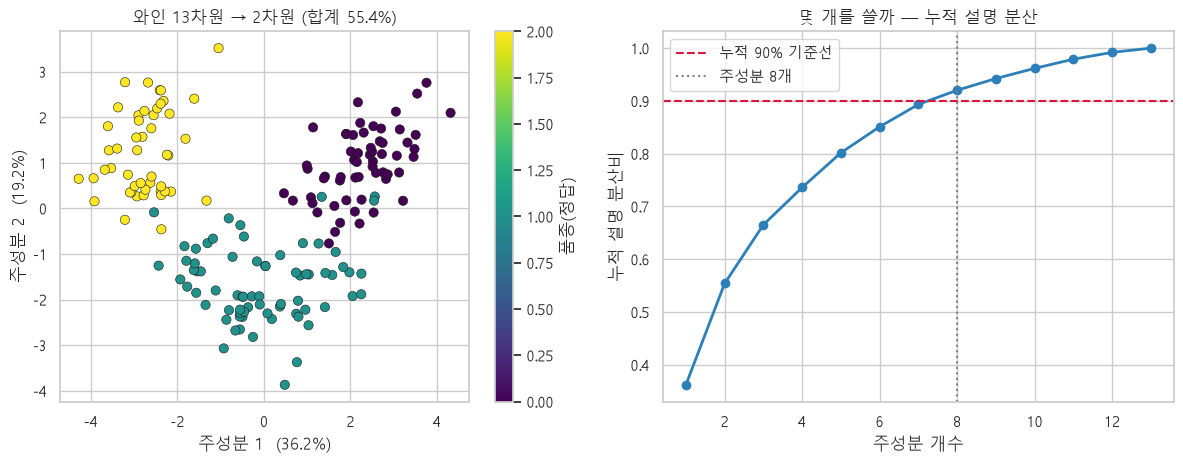

In [17]:
# ─────────────────────────────────────────────
# [C15] Part 5 · 📊 데이터로 확인해 봅시다 — 13개 피처를 2차원에
# 왼쪽: PCA 2D 산점도(품종 색) / 오른쪽: 누적 설명 분산 곡선
# ─────────────────────────────────────────────
X_pca2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xw)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sc = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=y_wine, cmap="viridis",
                     s=45, edgecolor="k", linewidth=0.4)
axes[0].set_xlabel(f"주성분 1  ({ratio[0]*100:.1f}%)")
axes[0].set_ylabel(f"주성분 2  ({ratio[1]*100:.1f}%)")
axes[0].set_title(f"와인 13차원 → 2차원 (합계 {cum[1]*100:.1f}%)")
plt.colorbar(sc, ax=axes[0], label="품종(정답)")

axes[1].plot(range(1, len(cum) + 1), cum, "o-", lw=2, color="#2c7fb8")
axes[1].axhline(0.90, color="crimson", ls="--", lw=1.5, label="누적 90% 기준선")
axes[1].axvline(n90, color="gray", ls=":", lw=1.5, label=f"주성분 {n90}개")
axes[1].set_xlabel("주성분 개수"); axes[1].set_ylabel("누적 설명 분산비")
axes[1].set_title("몇 개를 쓸까 — 누적 설명 분산")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# ─────────────────────────────────────────────
# ⌨️ 백문이 불여일타! (4) — 표준화를 빼면 PCA는 무엇을 찾는가
# ─────────────────────────────────────────────
wine = load_wine(as_frame=True)
X_wine, y_wine = wine.data, wine.target      # y는 채점용으로만 보관합니다

print(f"와인 데이터: {X_wine.shape[0]}병 × {X_wine.shape[1]}개 성분")
print(f"품종 분포: {y_wine.value_counts().sort_index().to_dict()}")

# ② 주성분을 전부 뽑아 설명 분산비를 봅니다
pca_all = PCA(random_state=RANDOM_STATE).fit(Xw)
ratio = pca_all.explained_variance_ratio_
cum = np.cumsum(ratio)

print("\n주성분별 설명 분산비 (상위 5개)")
for i in range(5):
    print(f"  PC{i+1}: {ratio[i]:.3f}   누적 {cum[i]:.3f}")

n90 = int(np.argmax(cum >= 0.90)) + 1
print(f"\nPC1+PC2 = {cum[1]:.3f}  → 2차원 그림은 전체 분산의 약 {cum[1]*100:.0f}%를 보존합니다")
print(f"누적 90%를 채우려면 주성분 {n90}개가 필요합니다 (13개 중)")

와인 데이터: 178병 × 13개 성분
품종 분포: {0: 59, 1: 71, 2: 48}

주성분별 설명 분산비 (상위 5개)
  PC1: 0.362   누적 0.362
  PC2: 0.192   누적 0.554
  PC3: 0.111   누적 0.665
  PC4: 0.071   누적 0.736
  PC5: 0.066   누적 0.802

PC1+PC2 = 0.554  → 2차원 그림은 전체 분산의 약 55%를 보존합니다
누적 90%를 채우려면 주성분 8개가 필요합니다 (13개 중)


In [19]:
# 일부러 스케일이 다른 피처를 만들어 비교
X_test = np.column_stack([
    np.random.randn(100),          # 평균 0, std 1
    np.random.randn(100) * 1000,   # 평균 0, std 1000
])

pca_raw    = PCA().fit(X_test)
pca_scaled = PCA().fit(StandardScaler().fit_transform(X_test))

print("표준화 전:", pca_raw.explained_variance_ratio_.round(3))
print("표준화 후:", pca_scaled.explained_variance_ratio_.round(3))
# 표준화 전: [1.000, 0.000]  ← std 1000짜리가 PC1을 독식
# 표준화 후: [0.500, 0.500]  ← 두 피처가 동등하게 기여

표준화 전: [1. 0.]
표준화 후: [0.568 0.432]


k별 실루엣: {2: 0.64, 3: 0.72, 4: 0.513, 5: 0.407, 6: 0.402}
→ 실루엣이 가장 높은 k = 3


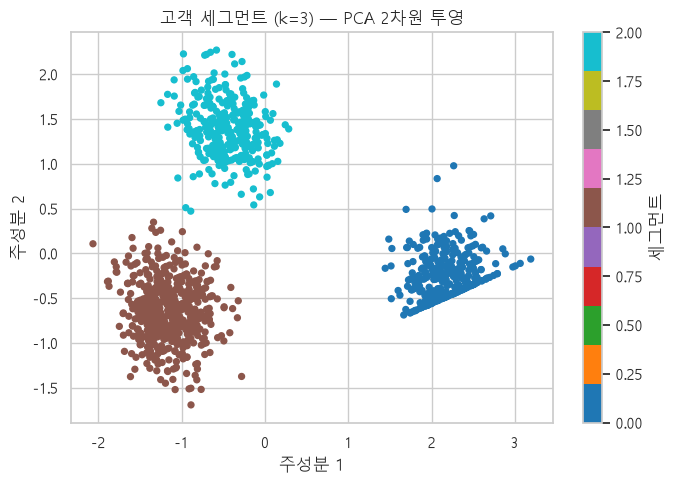


세그먼트 크기: {0: 349, 1: 539, 2: 312}


In [20]:
# ─────────────────────────────────────────────
# [C17] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 고객 세그먼트 찾기 — ① 스케일링 → ② k 결정 → ③ 군집화 → ④ PCA 2D
# (실행하면 k별 실루엣과 2D 산점도가 나옵니다)
# ─────────────────────────────────────────────
# ① 스케일링 — 단위가 다른 세 피처에 같은 가중치를 주기 위해 적용합니다 (시청은 시간, 세션은 회, 경과일은 일)
Xc = StandardScaler().fit_transform(cust[CUST_FEAT])

# ② k 결정 — 실루엣이 가장 높은 k
sil_k = {k: silhouette_score(Xc, KMeans(n_clusters=k, n_init=10,
                                        random_state=RANDOM_STATE).fit_predict(Xc))
         for k in range(2, 7)}
best_k = max(sil_k, key=sil_k.get)
print("k별 실루엣:", {k: round(v, 3) for k, v in sil_k.items()})
print(f"→ 실루엣이 가장 높은 k = {best_k}")

# ③ 군집화
cust["segment"] = KMeans(n_clusters=best_k, n_init=10,
                         random_state=RANDOM_STATE).fit_predict(Xc)

# ④ PCA 2D — 3차원을 2차원으로 눌러 눈으로 확인
Xc_2d = PCA(n_components=2).fit_transform(Xc)
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(Xc_2d[:, 0], Xc_2d[:, 1], c=cust["segment"], cmap="tab10", s=18)
ax.set_xlabel("주성분 1"); ax.set_ylabel("주성분 2")
ax.set_title(f"고객 세그먼트 (k={best_k}) — PCA 2차원 투영")
plt.colorbar(sc, ax=ax, label="세그먼트")
plt.tight_layout(); plt.show()

print(f"\n세그먼트 크기: {cust['segment'].value_counts().sort_index().to_dict()}")

In [21]:
# ─────────────────────────────────────────────
# [C18] Part 6 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기 세그먼트 프로파일 → 페르소나 이름과 액션으로 번역
# (실행하면 프로파일 표와 세그먼트 카드가 나옵니다)
# ─────────────────────────────────────────────
profile = cust.groupby("segment")[CUST_FEAT].mean().round(1)
profile["이탈률"] = cust.groupby("segment")["churn"].mean().round(3)
profile["인원"] = cust["segment"].value_counts().sort_index()

print("=== 세그먼트 프로파일 ===")
print(profile.to_string())

# 프로파일을 읽어 페르소나와 액션을 붙입니다 (판단은 사람이 합니다)
print("\n=== 세그먼트 카드(액션은 검증할 가설) ===")
for s, row in profile.iterrows():
    if row["days_since_last_watch"] > 35:
        persona, action = "이탈 임박 휴면", "복귀 메시지 실험 후보 (효과는 별도 검증)"
    elif row["watch_hours_last_month"] > 30:
        persona, action = "충성 단골", "유지 전략 실험 후보 (효과는 별도 검증)"
    else:
        persona, action = "저관여 라이트", "취향 기반 추천 실험 후보"
    print(f"\n[세그먼트 {s}] {persona}  ({int(row['인원'])}명, 이탈률 {row['이탈률']:.1%})")
    print(f"  근거: 지난달 시청 {row['watch_hours_last_month']:.0f}시간 · "
          f"월 {row['sessions_per_month']:.1f}회 시청 · 마지막 시청 {row['days_since_last_watch']:.0f}일 전")
    print(f"  액션: {action}")

print("\n→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.")

=== 세그먼트 프로파일 ===
         watch_hours_last_month  sessions_per_month  days_since_last_watch    이탈률   인원
segment                                                                               
0                          43.8                 9.5                    3.6  0.046  349
1                           8.8                 2.3                   19.8  0.173  539
2                          24.7                 5.4                   48.0  0.577  312

=== 세그먼트 카드(액션은 검증할 가설) ===

[세그먼트 0] 충성 단골  (349명, 이탈률 4.6%)
  근거: 지난달 시청 44시간 · 월 9.5회 시청 · 마지막 시청 4일 전
  액션: 유지 전략 실험 후보 (효과는 별도 검증)

[세그먼트 1] 저관여 라이트  (539명, 이탈률 17.3%)
  근거: 지난달 시청 9시간 · 월 2.3회 시청 · 마지막 시청 20일 전
  액션: 취향 기반 추천 실험 후보

[세그먼트 2] 이탈 임박 휴면  (312명, 이탈률 57.7%)
  근거: 지난달 시청 25시간 · 월 5.4회 시청 · 마지막 시청 48일 전
  액션: 복귀 메시지 실험 후보 (효과는 별도 검증)

→ 번호가 아니라 '이 세그먼트는 누구인가'로 번역해야 마케팅팀이 쓸 수 있습니다.


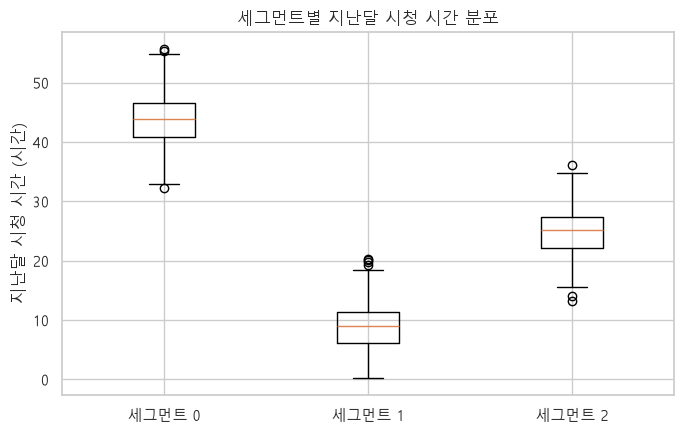

→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.


In [22]:
# ─────────────────────────────────────────────
# [C19] Part 5 · 📊 데이터로 확인해 봅시다 — 고객을 세 갈래로 나눠 보기
# 세그먼트별 지난달 시청 시간 분포 (실행하면 박스플롯이 그려집니다)
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
data_by_seg = [cust.loc[cust["segment"] == s, "watch_hours_last_month"].values
               for s in sorted(cust["segment"].unique())]
ax.boxplot(data_by_seg, tick_labels=[f"세그먼트 {s}" for s in sorted(cust["segment"].unique())])
ax.set_ylabel("지난달 시청 시간 (시간)")
ax.set_title("세그먼트별 지난달 시청 시간 분포")
plt.tight_layout()
plt.show()

print("→ 평균만 보면 놓치는 것이 보입니다 — 각 세그먼트 안에서도 편차가 있습니다.")

In [23]:
# ─────────────────────────────────────────────
# [C20] Part 7 · 📊 데이터로 확인해 봅시다 — 같은 표현으로 세 방식을 비교
# 군집 중심거리 피처 3방 비교 (실행하면 F1 평균과 차이가 출력됩니다)
# ─────────────────────────────────────────────
X_cust = cust[CUST_FEAT]
y_cust = cust["churn"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def lr():
    return LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

# ① 군집 파생 피처 없음
plain = Pipeline([("scale", StandardScaler()), ("clf", lr())])
s_plain = cross_val_score(plain, X_cust, y_cust, cv=cv, scoring="f1")

# ② Pipeline 안 KMeans — 각 겹의 학습 조각에서만 중심을 fit
feat = FeatureUnion([
    ("original", "passthrough"),
    ("cluster_distance", KMeans(n_clusters=3, n_init=10,
                                random_state=RANDOM_STATE)),
])
inside = Pipeline([("scale", StandardScaler()), ("feat", feat), ("clf", lr())])
s_inside = cross_val_score(inside, X_cust, y_cust, cv=cv, scoring="f1")

# ③ 전체 데이터로 스케일러·KMeans fit → 같은 중심거리 표현 생성 (누수)
scaler_all = StandardScaler().fit(X_cust)
X_scaled_all = scaler_all.transform(X_cust)
km_all = KMeans(n_clusters=3, n_init=10, random_state=RANDOM_STATE).fit(X_scaled_all)
X_leak = np.column_stack([X_scaled_all, km_all.transform(X_scaled_all)])
s_leak = cross_val_score(lr(), X_leak, y_cust, cv=cv, scoring="f1")

print("이탈 예측 F1 (층화 5겹 교차 검증)")
print(f"  ① 군집 파생 피처 없음         {s_plain.mean():.4f} ± {s_plain.std():.4f}")
print(f"  ② Pipeline 안 중심거리 (정상) {s_inside.mean():.4f} ± {s_inside.std():.4f}"
      f"   변화 {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  ③ 전체-fit 중심거리 (누수)    {s_leak.mean():.4f} ± {s_leak.std():.4f}"
      f"   변화 {s_leak.mean() - s_plain.mean():+.4f}")
print()
print(f"→ 관측된 파생 피처 효과 (② − ①) {s_inside.mean() - s_plain.mean():+.4f}")
print(f"  전체-fit과 정상 절차 차이 (③ − ②) {s_leak.mean() - s_inside.mean():+.4f}")

이탈 예측 F1 (층화 5겹 교차 검증)
  ① 군집 파생 피처 없음         0.4751 ± 0.0302
  ② Pipeline 안 중심거리 (정상) 0.5125 ± 0.0513   변화 +0.0374
  ③ 전체-fit 중심거리 (누수)    0.5116 ± 0.0434   변화 +0.0365

→ 관측된 파생 피처 효과 (② − ①) +0.0374
  전체-fit과 정상 절차 차이 (③ − ②) -0.0009


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import StratifiedKFold, cross_val_score

RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def lr():
    return LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

# 기준선 (k 없음)
plain = Pipeline([("scale", StandardScaler()), ("clf", lr())])
s_plain = cross_val_score(plain, X_cust, y_cust, cv=cv, scoring="f1").mean()

# k = 2, 3, 4, 5 순회
results = []
for k in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
    feat = FeatureUnion([
        ("original", "passthrough"),
        ("cluster_distance", KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])
    pipe = Pipeline([("scale", StandardScaler()), ("feat", feat), ("clf", lr())])
    score = cross_val_score(pipe, X_cust, y_cust, cv=cv, scoring="f1").mean()
    results.append((k, score, score - s_plain))

# 출력
print(f"{'k':>4}  {'F1 평균':>8}  {'vs 기준선':>10}")
print("-" * 28)
print(f"{'기준':>4}  {s_plain:.4f}")
for k, f1, delta in results:
    print(f"  {k}    {f1:.4f}    {delta:+.4f}")

best_k, best_f1, best_delta = max(results, key=lambda x: x[1])
print(f"\n→ 최적 k = {best_k}  (F1 = {best_f1:.4f},  기준 대비 {best_delta:+.4f})")

   k     F1 평균      vs 기준선
----------------------------
  기준  0.4751
  2    0.4774    +0.0023
  3    0.5125    +0.0374
  4    0.5169    +0.0418
  5    0.5206    +0.0455
  6    0.5199    +0.0448
  7    0.5199    +0.0448
  8    0.5289    +0.0539
  9    0.5270    +0.0520
  10    0.5299    +0.0548

→ 최적 k = 10  (F1 = 0.5299,  기준 대비 +0.0548)


In [26]:
import numpy as np
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import BaseEstimator, TransformerMixin

class RandomFeatures(BaseEstimator, TransformerMixin):
    """KMeans와 동일한 피처 수의 랜덤 가우시안 피처 생성"""
    def __init__(self, n_features=3, random_state=42):
        self.n_features = n_features
        self.random_state = random_state
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        rng = np.random.RandomState(self.random_state)
        return rng.randn(len(X), self.n_features)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def lr():
    return LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

plain = Pipeline([("scale", StandardScaler()), ("clf", lr())])
s_plain = cross_val_score(plain, X_cust, y_cust, cv=cv, scoring="f1").mean()

print(f"{'k':>4}  {'KMeans F1':>10}  {'Random F1':>10}  {'KMeans-Random':>14}")
print("-" * 46)
print(f"{'기준':>4}  {s_plain:.4f}")

for k in [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]:
    # KMeans 피처
    feat_km = FeatureUnion([
        ("original", "passthrough"),
        ("cluster_distance", KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)),
    ])
    pipe_km = Pipeline([("scale", StandardScaler()), ("feat", feat_km), ("clf", lr())])
    s_km = cross_val_score(pipe_km, X_cust, y_cust, cv=cv, scoring="f1").mean()

    # 랜덤 피처 (동일한 피처 수 k개)
    feat_rnd = FeatureUnion([
        ("original", "passthrough"),
        ("random", RandomFeatures(n_features=k, random_state=RANDOM_STATE)),
    ])
    pipe_rnd = Pipeline([("scale", StandardScaler()), ("feat", feat_rnd), ("clf", lr())])
    s_rnd = cross_val_score(pipe_rnd, X_cust, y_cust, cv=cv, scoring="f1").mean()

    diff = s_km - s_rnd
    marker = " ← 의미 없음" if diff < 0.005 else ""
    print(f"  {k:>2}    {s_km:.4f}      {s_rnd:.4f}      {diff:+.4f}{marker}")

   k   KMeans F1   Random F1   KMeans-Random
----------------------------------------------
  기준  0.4751
   2    0.4774      0.4919      -0.0146 ← 의미 없음
   3    0.5125      0.4859      +0.0266
   4    0.5169      0.4938      +0.0231
   5    0.5206      0.4692      +0.0514
   6    0.5199      0.5063      +0.0136
   7    0.5199      0.4985      +0.0214
   8    0.5289      0.4839      +0.0451
   9    0.5270      0.4781      +0.0490
  10    0.5299      0.4729      +0.0570
  15    0.5216      0.4485      +0.0730
  20    0.5277      0.4675      +0.0602
